# Agent Frameworks - Pydantic AI Additional Lab
This code below implements an asynchronous, multi-agent AI marketing translation pipeline using Pydantic AI and its native state-machine engine, Pydantic Graph (pydantic_graph). [1] 

## 1. Setup

Following the instructions in the ["Day 2: Pydantic AI Notebook"](../../2_strands_pydantic/pydantic_lab.ipynb).

If you want to see more details on its configuration, take a look at the end section here: ["Appendix - Additional Setup Instructions"](#appendix---additional-setup-instructions)

## 2. A graph-based **workflow engine** with human-in-the-loop approval
The proposal follows a data class-driven graph architecture. It connects a local Ollama SLM (Qwen 2.5:7b) using an OpenAI client abstraction and integrates an open-source MCP (Model Context Protocol) file system server via fastmcp to securely manage file writes within a local sandbox directory. [2]

### Step-by-Step Actions of the Code
```text
[Start Node] 
     │
     ▼
[write_tagline] ──► [translate] ──► [ask_human] ──► (Decision Node)
                                                         │
                                        ┌────────────────┴───────────-─────┐
                                        ▼ (If "y"/"yes")                   ▼ (If "n"/"no")
                                   [save_file]                             │
                                        │                                  │
                                        └─────────────────────────────────►|
                                                                           ▼
                                                                      [format_output] ──► [End Node]
```
### 2.1. Environment and Storage Initialization
* Loads target environment credentials via dotenv.
* Resolves an absolute path named workspace and programmatically builds it if missing.
* Bootstraps an asynchronous MCPToolset worker process using an npx command pipeline targeting the @modelcontextprotocol/server-filesystem script.

### 2.2. Client and Agent Setup
* Spawns an OpenAIChatModel pointing to a local deployment port (OLLAMA_API_BASE).
* Declares WriterAgent to generate market text strings without quotation boundaries.
* Declares TranslatorAgent to evaluate text parameters and output exact translations.

### 2.3. State Management Configuration
* Defines a plain Python @dataclass structure named WorkflowState to preserve data across execution frames.
* Instantiates a GraphBuilder mapping the dataclass state constraint and declaring a final global return type signature of <class 'str'>.

### 2.4. Execution Step Implementations (@g.step)
* write_tagline: Ingests the initial prompt string, invokes the writer agent to generate an English slogan, and passes it forward.
* translate: Receives the tagline text, queries the translator agent to map the string into natural Spanish, and provides a pre-baked static text fallback if the local model returns an empty block.
* ask_human: Commits the translation string into the shared ctx.state.saved_text memory. It prints a preview block on the console screen and freezes the thread loop via a main-thread input() prompt to capture user selection keystrokes.
* save_file: Opens the asynchronous MCP toolset sub-process. It calls the write_file macro to dump the translation string payload into a target named translate.txt. If the sub-process connection throws an exception, it uses standard Python context handlers to execute a local manual disk write fallback.
* format_output: Extracts the translation string from memory variables or upstream inputs and returns a modified string converting the characters into uppercase.

### 2.5. Graph Compilation and Workflow Triggering
* Links individual nodes together sequentially using directional layout constraints (g.edge_from().to()).
* Adds a conditional g.decision() branching junction that evaluates the string output generated by the ask_human node. If it receives "y" or "yes", it routes the graph to save_file; otherwise, it bypasses storage actions and forwards directly to format_output.
* Compiles the pipeline layout via g.build() and schedules workflow.run() asynchronously inside a standard main() event wrapper loop.

[1] [https://www.youtube.com](https://www.youtube.com/watch?v=HCSLdpmSyOM)
[2] [https://www.youtube.com](https://www.youtube.com/watch?v=Lj7yO3afWyQ)

In [9]:
import asyncio
import os
from dataclasses import dataclass

from dotenv import load_dotenv
from pydantic_graph import GraphBuilder, StepContext
from pydantic_ai import Agent
from pydantic_ai.mcp import MCPToolset
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider
from fastmcp.client.transports import StdioTransport

load_dotenv(override=True)

# -------------------------------------------------------------------
# Workspace & Tool Setup
workspace = os.path.abspath("workspace")
os.makedirs(workspace, exist_ok=True)

filesystem_toolset = MCPToolset(
    StdioTransport(
        command="npx",
        args=["-y", "@modelcontextprotocol/server-filesystem", workspace],
        cwd=workspace,
    )
)

# -------------------------------------------------------------------
# MODEL CLIENT (OLLAMA TARGET)
# Ollama exposes an OpenAI-compatible endpoint, so we reuse OpenAIChatModel
# with a custom base_url, same idea as agent_framework's OpenAIChatCompletionClient.
ollama_model = OpenAIChatModel(
    "qwen2.5:7b",
    provider=OpenAIProvider(
        base_url=os.getenv("OLLAMA_API_BASE", "http://localhost:11434/v1"),
        api_key="ollama",
    ),
)

# -------------------------------------------------------------------
# WORKER AGENTS
writer_agent = Agent(
    ollama_model,
    instructions="You are a professional creative marketer. Write a concise, 1-sentence product tagline. Do not use quotation marks.",
    name="WriterAgent",
)

# Only the translator needs filesystem access in this workflow (matches the
# original: the FileSaver step is the one that writes to disk), but nothing
# stops you from attaching the toolset to any/all agents that need it.
translator_agent = Agent(
    ollama_model,
    instructions="You are an expert translator. Translate the given text exactly into natural Spanish. Return only the final Spanish text.",
    name="TranslatorAgent",
)

# -------------------------------------------------------------------
# GRAPH STATE
# Unlike agent_framework's State (pending/commit buffer, .get()/.set() only),
# pydantic_graph's state is just a plain dataclass instance you mutate directly
# via ctx.state.<field> = value. It's passed into graph.run(state=...) and
# threaded through every step automatically.
@dataclass
class WorkflowState:
    saved_text: str = ""

# -------------------------------------------------------------------
# BUILD THE GRAPH
g = GraphBuilder(state_type=WorkflowState, output_type=str)

@g.step
async def write_tagline(ctx: StepContext[WorkflowState, None, str]) -> str:
    """
    Invokes the writer agent to generate a marketing tagline based on the input text.

    Args:
        ctx: The step context containing the input prompt string from the previous step.

    Returns:
        str: The generated tagline output from the writer agent.
    """
    print("\n🚀 [AGENT INITIALIZED] Running writer agent...")
    print(f"📥 [LATEST INPUT]: {ctx.inputs}")
    result = await writer_agent.run(ctx.inputs)
    print(f"📤 [AGENT RESPONSE]: {result.output}")
    return result.output


@g.step
async def translate(ctx: StepContext[WorkflowState, None, str]) -> str:
    """
    Invokes the translator agent to translate the provided text into the 
    target language.
    
    If the agent returns an empty response, a default organic energy drink 
    tagline in Spanish is applied as a fallback.

    Args:
        ctx: The step context containing the text string to be translated.

    Returns:
        str: The translated text, or the default fallback tagline if empty.
    """
    print("\n🚀 [AGENT INITIALIZED] Running translator agent...")
    print(f"📥 [LATEST INPUT]: {ctx.inputs}")
    result = await translator_agent.run(ctx.inputs)
    text = result.output.strip() or "Una bebida energética orgánica de alto rendimiento para programadores."
    print(f"📤 [AGENT RESPONSE]: {text}")
    return text


@g.step
async def ask_human(ctx: StepContext[WorkflowState, None, str]) -> str:
    """
    Displays a translation preview to the user and blocks until they provide
    console input confirming whether they want to save the output.
    
    Also stashes the current input into the global graph state.
    """
    ctx.state.saved_text = ctx.inputs

    print(f"\n🔍 [TRANSLATION PREVIEW]:\n{ctx.inputs}")
    choice = input("💾 Would you like to save this translation to a file? (y/n): ").strip().lower()
    return choice


@g.step
async def save_file(ctx: StepContext[WorkflowState, None, str]) -> str:
    """
    Persists the stashed text from the workflow state to a file.
    
    Attempts to use the Model Context Protocol (MCP) Filesystem toolset first. 
    If the MCP tool call fails, it falls back to standard synchronous local 
    file system operations.

    Args:
        ctx: The step context containing the global graph state.

    Returns:
        str: The raw text that was saved to disk.
    """
    text_to_save = ctx.state.saved_text
    print("\n🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...")

    try:
        async with filesystem_toolset:
            await filesystem_toolset.direct_call_tool(
                "write_file", {"path": "pydabtic_translate.txt", "content": text_to_save}
            )
        print("✨ SUCCESS: MCP tool written to pydabtic_translate.txt.")
    except Exception as e:
        print(f"⚠️ Direct MCP call failed ({e}). Falling back to manual write...")
        file_path = os.path.join(workspace, "pydabtic_translate.txt")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_to_save)
        print(f"✨ Fallback SUCCESS: File created at {file_path}")

    return text_to_save


@g.step
async def format_output(ctx: StepContext[WorkflowState, None, str]) -> str:
    """
    Formats the workflow text into a standardized uppercase brand presentation string.
    
    Prioritizes text incoming from the immediate previous step (`ctx.inputs`). 
    If no input is present, it falls back to reading the stashed text directly 
    from the global graph state (`ctx.state.saved_text`).

    Args:
        ctx: The step context containing the incoming string or graph state.

    Returns:
        str: The final stylized and capitalized text string.
    """
    text_to_format = ctx.inputs if ctx.inputs else ctx.state.saved_text
    return f"*** BRAND OUTPUT ***\n{text_to_format.upper()}"


g.add(
    g.edge_from(g.start_node).to(write_tagline),
    g.edge_from(write_tagline).to(translate),
    g.edge_from(translate).to(ask_human),

    # Conditional branch: ask_human returns "y"/"n" and the decision node
    # routes accordingly - the direct equivalent of should_save/should_skip
    # conditions on WorkflowBuilder.add_edge in agent_framework.
    g.edge_from(ask_human).to(
        g.decision()
        .branch(g.match(str, matches=lambda choice: choice in ("y", "yes")).to(save_file))
        .branch(g.match(str, matches=lambda choice: choice not in ("y", "yes")).to(format_output))
    ),

    g.edge_from(save_file).to(format_output),
    g.edge_from(format_output).to(g.end_node),
)

workflow = g.build()

# -------------------------------------------------------------------
# RUN THE WORKFLOW
async def main():
    print("🎬 Starting multi-agent Ollama Workflow (Pydantic AI)...")

    result = await workflow.run(
        state=WorkflowState(),
        inputs="A high-performance organic energy drink for programmers.",
    )

    print("\n🏁 [WORKFLOW EXECUTION COMPLETE]")
    print(result)


await main()

🎬 Starting multi-agent Ollama Workflow (Pydantic AI)...

🚀 [AGENT INITIALIZED] Running writer agent...
📥 [LATEST INPUT]: A high-performance organic energy drink for programmers.
📤 [AGENT RESPONSE]: Fuel your code with nature's power.

🚀 [AGENT INITIALIZED] Running translator agent...
📥 [LATEST INPUT]: Fuel your code with nature's power.
📤 [AGENT RESPONSE]: Sobrie tu código con el poder de la naturaleza.

🔍 [TRANSLATION PREVIEW]:
Sobrie tu código con el poder de la naturaleza.

🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...
✨ SUCCESS: MCP tool written to pydabtic_translate.txt.

🏁 [WORKFLOW EXECUTION COMPLETE]
*** BRAND OUTPUT ***
SOBRIE TU CÓDIGO CON EL PODER DE LA NATURALEZA.


### Let's see its workflow diagram

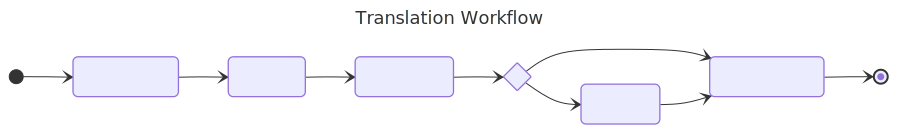

In [7]:
import base64
import requests
from IPython.display import SVG, display

def show_mermaid(code: str):
    graphbytes = code.encode("utf8")
    base64_string = base64.urlsafe_b64encode(graphbytes).decode("ascii")
    url = f"https://mermaid.ink/svg/{base64_string}"

    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=15)

    if resp.status_code != 200:
        print(f"Failed ({resp.status_code}): {resp.text[:300]}")
        return None

    display(SVG(data=resp.content))

show_mermaid(workflow.render(title="Translation Workflow", direction="LR"))

## Appendix - Additional Setup Instructions

In Pydantic AI, you set the seed, temperature, and other generation parameters by passing a model_settings dictionary to either the Agent constructor or directly inside the runtime execution context.
Since Pydantic AI is provider-agnostic, you can use standard settings names that map directly to your local Ollama instance under the hood. [1] 
Here are the two ways to apply these model configurations to your script:

### Option 1: Configure via the Agent Constructor (Recommended)
This applies the parameters globally to every turn that specific agent makes. You can pass them as a typed dictionary right below your ollama_model reference:
```python
from pydantic_ai import Agent

# Define your settings mapping layout
ollama_settings = {
    'temperature': 0.1,    # Set lower temperature for focused, deterministic outputs
    'seed': 42,            # Fixed seed to ensure repeatable generations
    'max_tokens': 150,     # Stop generation after 150 tokens
    'top_p': 0.9           # Nucleus sampling boundary constraint
}

# Apply the parameters directly to your workflow agents
writer_agent = Agent(
    ollama_model,
    instructions="You are a professional creative marketer...",
    name="WriterAgent",
    model_settings=ollama_settings  # ✨ Injected here
)

# You can set different model settings for each agent
translator_agent = Agent(
    ollama_model,
    instructions="You are an expert translator...",
    name="TranslatorAgent",
    model_settings=ollama_settings  # ✨ Injected here
)
```
### Option 2: Pass Settings Dynamically at Runtime
If you want to use different generation rules for different parts of your graph steps (for example, keeping the WriterAgent highly creative with a high temperature, but making the TranslatorAgent strictly logical), you can pass model_settings into the .run() method inside your graph nodes:
```python
@g.stepasync def write_tagline(ctx: StepContext[WorkflowState, None, str]) -> str:
    print("\n🚀 Running writer agent...")
    
    # Pass settings directly to the execution block override
    result = await writer_agent.run(
        ctx.inputs,
        model_settings={'temperature': 0.8, 'seed': 42, 'max_tokens': 50} # 🔥 Creative tagline
    )
    return result.output

@g.stepasync def translate(ctx: StepContext[WorkflowState, None, str]) -> str:
    print("\n🚀 Running translator agent...")
    
    # Use deterministic overrides for translation
    result = await translator_agent.run(
        ctx.inputs,
        model_settings={'temperature': 0.0, 'seed': 42} # ❄️ Strict, precise mapping
    )
    return result.output.strip()
```

### Available Settings Reference for Ollama
The core properties available in Pydantic AI's ModelSettings configuration wrapper include:
* temperature (float): Bounded usually between 0.0 and 2.0. Controls randomness.
* seed (int): Anchor value to eliminate variance across repetitive script calls.
* max_tokens (int): Hard boundary to limit long text completions.
* top_p (float): Cuts off less likely word choices based on cumulative probability thresholds.
* presence_penalty / frequency_penalty (float): discourage phrase repetition loops. [2] 

[1] [https://pydantic.dev](https://pydantic.dev/docs/ai/models/overview/)
[2] [https://www.runcomfy.com](https://www.runcomfy.com/comfyui-nodes/ACE-Step-ComfyUI/ace-step-settings)

---

### ModelSettings configuration class
In pydantic_ai, the ModelSettings configuration class provides several cross-provider parameters. Because the library is model-agnostic, these settings are designed to map smoothly to different LLMs like OpenAI, Anthropic, Gemini, and Groq. [1, 2] 

The core settings available in the [pydantic_ai Settings API](https://pydantic.dev/docs/ai/api/pydantic-ai/settings/) include:
#### Available Model Settings
* max_tokens (int | None): The maximum number of tokens the model should generate before stopping.
* top_p (float | None): An alternative to sampling with temperature (nucleus sampling). It limits the pool of tokens to only those whose cumulative probability meets the threshold (e.g., 0.9 means only the top 90% most likely tokens are considered).
* top_k (int | None): Limits the token pool strictly to the top K most probable choices for each step. (Commonly supported by Anthropic and Gemini).
* seed (int | None): Sets a random seed for the model. If supported by the provider (like OpenAI), this makes the output deterministic and repeatable.
* timeout (float | tuple[float, float] | None): Overrides the client-level default timeout limit for a specific request.
* thinking (ThinkingLevel | None): Controls internal reasoning or thinking behaviors for reasoning-optimized models. [2, 3] 

#### Using the Typed Settings Object
While you can pass these settings as a standard Python dictionary, importing and using the ModelSettings class is highly recommended. It provides autocomplete and type-checking warnings in your IDE if you misspell a parameter. [2, 4] 
```python
from pydantic_ai import Agent
from pydantic_ai.settings import ModelSettings

# Pass a group of settings directly to the agent
agent = Agent(
    'openai:gpt-4o',
    model_settings=ModelSettings(
        temperature=0.3,
        max_tokens=500,
        seed=42,
        timeout=10.0
    )
)
```
(Note: Not all models or providers support every parameter listed above. If you pass a parameter that a specific provider doesn't support, it will typically be ignored silently at runtime.) [2, 4] 

Would you like an example of how to dynamically change these settings mid-conversation using a callback function, or are you tracking a specific parameter for a provider like Anthropic or OpenAI? [1, 5] 

[1] [https://pydantic.dev](https://pydantic.dev/docs/ai/models/overview/)
[2] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/pydantic-ai/settings/)
[3] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/models/base/)
[4] [https://github.com](https://github.com/pydantic/pydantic-ai/issues/856)
[5] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/pydantic-ai/agent/)

### Configuring model_settings in an Agent.
There are provider-specific settings and advanced parameters available inside model_settings. [1] 
Because pydantic_ai is built to be cross-compatible, it uses Python's TypedDict behavior under the hood for ModelSettings. This allows you to pass standard parameters, provider-specific fields, or even raw request overrides directly to the underlying API clients. [1, 2, 3, 4, 5] 

#### 1. Provider-Specific Service Tiers
If you use enterprise or paid tiers that offer higher rate limits or discounted routing, you can control the routing tier using these settings: [2, 6] 
* service_tier (Literal['auto', 'default']): The unified cross-provider field to define the scale tier.
* openai_service_tier (str): Maps directly to OpenAI's scale tiers (e.g., openai_service_tier="scale").
* anthropic_service_tier (str): Directs performance routing for Anthropic.
* google_cloud_service_tier / bedrock_service_tier: System tiers for Vertex AI and AWS Bedrock. [2, 6] 

#### 2. Presence & Frequency Penalties (OpenAI/Groq)
These control how repetitive the model is allowed to be: [2, 4, 7, 8] 
* presence_penalty (float): Positive values penalize new tokens based on whether they have appeared in the text so far, encouraging the model to introduce new topics. [4, 7, 9, 10, 11] 
* frequency_penalty (float): Positive values penalize new tokens based on their existing frequency in the text, decreasing the likelihood of the model repeating the exact same phrases. [4, 7, 9, 12, 13] 

#### 3. Deep-Level Request Overrides (Escape Hatches)
If a model provider rolls out a brand-new feature that pydantic_ai hasn't explicitly added to its core code yet, you can pass parameters straight to the client payload via these "extra" settings: [2, 4] 
* extra_body (dict[str, Any]): Injects parameters directly into the JSON request body sent to the model provider. Useful for provider-specific beta features.
* extra_headers (dict[str, str]): Passes custom HTTP headers along with the API request.
* extra_query (dict[str, str]): Adds extra query parameters to the target API endpoint URL. [2, 4, 14] 

```python
from pydantic_ai import Agent

agent = Agent(
    'openai:gpt-4o',
    model_settings={
        'temperature': 0.1,
        'presence_penalty': 0.5,
        # Escape hatch example: Passing a hypothetical alpha parameter directly to OpenAI
        'extra_body': {
            'custom_beta_feature_flag': True
        }
    }
)
```
#### Dynamic model_settings
You do not have to keep model_settings completely static. You can pass a callable function to model_settings instead of a dictionary. This function reads the current context (RunContext) and adjusts settings dynamically at each step: [15, 16] 
```python
from pydantic_ai import Agent, RunContext
from pydantic_ai.settings 
import ModelSettings

def dynamic_settings(ctx: RunContext) -> ModelSettings:
    # Example: If the user message is incredibly long, dynamically lower the max_tokens
    return ModelSettings(temperature=0.2, max_tokens=100)

agent = Agent('openai:gpt-4o', model_settings=dynamic_settings)
```

[1] [https://pydantic.dev](https://pydantic.dev/docs/ai/core-concepts/agent/)
[2] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/pydantic-ai/settings/)
[3] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/pydantic-ai/settings/)
[4] [https://openai.github.io](https://openai.github.io/openai-agents-python/ref/model_settings/)
[5] [https://www.projectpro.io](https://www.projectpro.io/article/pydantic-ai/1088)
[6] [https://github.com](https://github.com/pydantic/pydantic-ai/blob/main/pydantic_ai_slim/pydantic_ai/models/openai.py)
[7] [https://openai.github.io](https://openai.github.io/openai-agents-js/openai/agents/type-aliases/modelsettings/)
[8] [https://medium.com](https://medium.com/@abhinav.dobhal/the-complete-guide-to-building-production-ready-ai-agents-in-n8n-3c50807003ae)
[9] [https://www.youtube.com](https://www.youtube.com/watch?v=Q1ljY_tALZU&t=790)
[10] [https://microsoft.github.io](https://microsoft.github.io/autogen/stable//reference/python/autogen_ext.models.openai.html)
[11] [https://openai.github.io](https://openai.github.io/openai-agents-js/guides/models/)
[12] [https://inspect.aisi.org.uk](https://inspect.aisi.org.uk/reference/inspect_eval-set.html)
[13] [https://learn.microsoft.com](https://learn.microsoft.com/en-us/dotnet/api/microsoft.semantickernel.connectors.azureopenai.azureopenaipromptexecutionsettings?view=semantic-kernel-dotnet)
[14] [https://docs.ag2.ai](https://docs.ag2.ai/latest/docs/user-guide/models/openai/)
[15] [https://pydantic.dev](https://pydantic.dev/docs/ai/api/pydantic-ai/agent/)
[16] [https://pydantic.dev](https://pydantic.dev/docs/ai/core-concepts/agent/)

---
### Define a structured output
In pydantic_ai, you enforce a structured data format by passing a Pydantic model into the result_type parameter of the agent.
The library uses this schema to automatically instruct the LLM, validate the response, and return a fully typed Python object instead of raw text. [1, 2, 3] 

#### Step-by-Step Example
Here is how to define a structured output format, pass it to your agent, and extract the validated data.
```python
from pydantic import BaseModel, Fieldfrom pydantic_ai 
import Agent

# 1. Define your desired output structure using Pydantic
class HeroProfile(BaseModel):
    name: str = Field(description="The hero's superhero alias")
    secret_identity: str
    powers: list[str] = Field(description="List of their primary superpowers")
    power_level: int = Field(description="Scale from 1 to 10")

# 2. Pass the Pydantic class to the result_type parameter
agent = Agent(
    'openai:gpt-4o',
    result_type=HeroProfile, # Enforces structured data output
    system_prompt="Extract superhero data from the provided text."
)
# 3. Run the agent
result = agent.run_sync("Clark Kent is a reporter who flies and has super strength. He goes by Superman and is easily a level 10.")
# 4. Access the data directly as a typed Python object
print(f"Name: {result.data.name}")
print(f"Powers: {result.data.powers}")
```
#### Key Features of Structured Outputs
* Automatic Type Conversion: The result.data property contains a real instance of your HeroProfile class, not a string or JSON dictionary.
* Built-in Auto-Retry: If the LLM returns invalid JSON or fails your Pydantic validation checks (e.g., passing a string for an int field), pydantic_ai will automatically catch the error, send it back to the LLM, and ask it to fix its mistake. [4, 5, 6] 
* Native Tool/Function Calling: Under the hood, the library translates your Pydantic schema into structured tools (like OpenAI's structured outputs or tool schemas), ensuring the highest possible formatting accuracy from the provider. [7, 8] 

[1] [https://medium.com](https://medium.com/@mauryaanoop3/unlocking-the-power-of-structured-outputs-with-ollama-0eeccfca7cab)
[2] [https://apxml.com](https://apxml.com/courses/langchain-production-llm/chapter-1-advanced-langchain-architecture/advanced-output-parsing)
[3] [https://www.opcito.com](https://www.opcito.com/blogs/langchain-for-clean-object-based-responses-from-llmss)
[4] [https://python.useinstructor.com](https://python.useinstructor.com/learning/validation/basics/)
[5] [https://docs.instructorphp.com](https://docs.instructorphp.com/packages/instructor/introduction)
[6] [https://medium.com](https://medium.com/data-science-collective/how-to-keep-llm-outputs-predictable-using-pydantic-validation-39daa20fd946)
[7] [https://engineering.fractional.ai](https://engineering.fractional.ai/openai-structured-output-fixes)
[8] [https://docs.ag2.ai](https://docs.ag2.ai/latest/docs/use-cases/notebooks/notebooks/agentchat_bedrock_client_structured_output/)
